In [21]:
# ── CELL 1: All imports ─────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ All imports loaded")

✓ All imports loaded


In [22]:
# ── CELL 2: Load ────────────────────────────────────
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Shape: {df.shape}")
print(f"\nColumn names:")
print(df.columns.tolist())
df.head(5)

Shape: (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [23]:
# ── CELL 3a: Data types ─────────────────────────────
print("=== DATA TYPES ===")
print(df.dtypes)

# ── CELL 3b: Missing values ─────────────────────────
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

# ── CELL 3c: Duplicates ─────────────────────────────
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# ── CELL 3d: Target distribution ────────────────────
churn_counts = df['Churn'].value_counts()
churn_rate = (df['Churn'] == 'Yes').mean() * 100
print(f"\nChurn distribution:\n{churn_counts}")
print(f"\nChurn rate: {churn_rate:.1f}%")

# ── CELL 3e: The TotalCharges problem ───────────────
# TotalCharges is OBJECT dtype — this is the known issue
print("\nTotalCharges dtype:", df['TotalCharges'].dtype)
print("Sample of blanks:")
print(df[df['TotalCharges'].str.strip() == ''][['customerID', 'tenure', 'TotalCharges']].head(11))

# ── CELL 3f: Summary statistics ─────────────────────
df.describe(include='all').T

=== DATA TYPES ===
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

=== MISSING VALUES ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
Pap

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
# ── CELL 4: Data Cleaning ───────────────────────────
df_clean = df.copy()

# 4a. Fix TotalCharges — convert to float, impute blanks
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
n_blanks = df_clean['TotalCharges'].isnull().sum()
median_tc = df_clean['TotalCharges'].median()
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(median_tc)
print(f"Fixed {n_blanks} blank TotalCharges values (imputed with median: ${median_tc:.2f})")

# 4b. Drop customerID (identifier — never a feature)
df_clean = df_clean.drop(columns=['customerID'])

# 4c. Encode binary target
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

# 4d. Encode binary columns
binary_yes_no = ['Partner', 'Dependents', 'PhoneService',
                 'PaperlessBilling']
for col in binary_yes_no:
    df_clean[col] = df_clean[col].map({'Yes': 1, 'No': 0})

df_clean['gender'] = df_clean['gender'].map({'Female': 1, 'Male': 0})

# 4e. Recode "No internet service" and "No phone service" → 0
internet_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in internet_cols:
    df_clean[col] = df_clean[col].map({'Yes': 1, 'No': 0,
                                        'No internet service': 0})

df_clean['MultipleLines'] = df_clean['MultipleLines'].map({
    'Yes': 1, 'No': 0, 'No phone service': 0
})

# 4f. One-hot encode multi-class categoricals
df_clean = pd.get_dummies(df_clean,
    columns=['InternetService', 'Contract', 'PaymentMethod'],
    drop_first=True)

# 4g. Final check
print(f"\nFinal shape: {df_clean.shape}")
print(f"Missing values remaining: {df_clean.isnull().sum().sum()}")
print(f"Churn rate: {df_clean['Churn'].mean()*100:.1f}%")
df_clean.head(3)

Fixed 11 blank TotalCharges values (imputed with median: $1397.47)

Final shape: (7043, 24)
Missing values remaining: 0
Churn rate: 26.5%


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,False,False,False,False,False,True,False
1,0,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,False,False,True,False,False,False,True
2,0,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,False,False,False,False,False,False,True


In [25]:
# ── CELL 5: Save ────────────────────────────────────
df_clean.to_csv('../data/processed/churn_clean.csv', index=False)
print("✓ Saved churn_clean.csv")
print(f"Columns: {list(df_clean.columns)}")

✓ Saved churn_clean.csv
Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


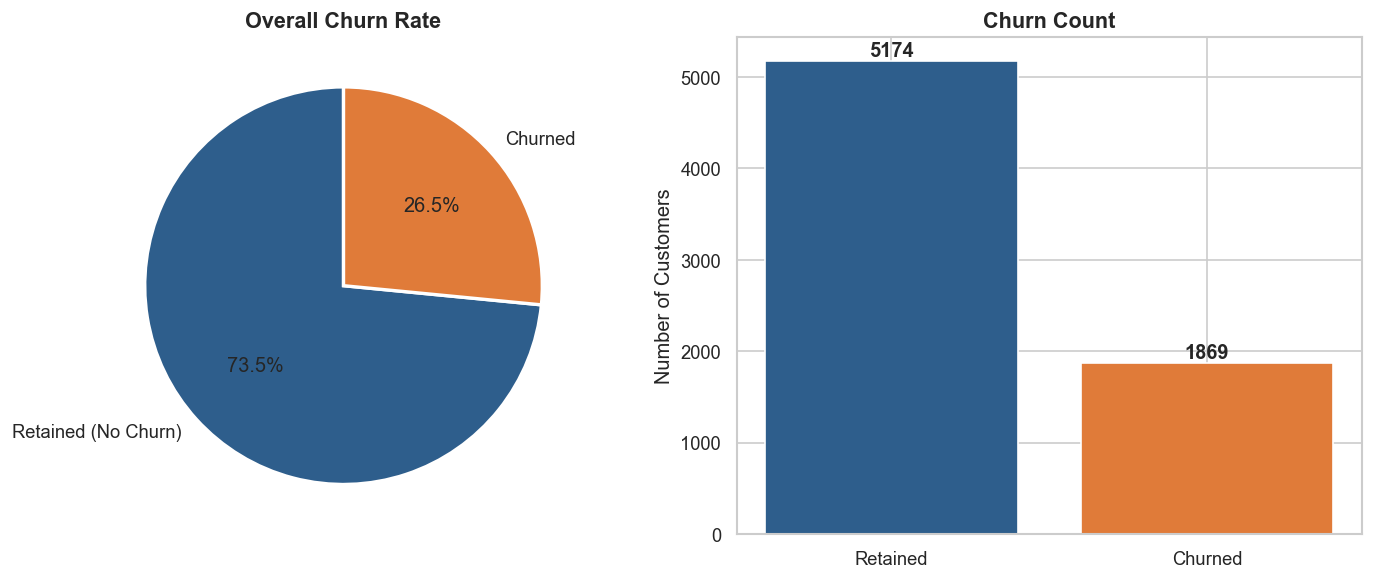

In [26]:
# ── CELL 6: Churn Distribution ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
labels = ['Retained (No Churn)', 'Churned']
sizes  = [df_clean['Churn'].value_counts()[0], df_clean['Churn'].value_counts()[1]]
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%',
            colors=['#2E5E8C', '#E07B39'],
            wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            startangle=90)
axes[0].set_title('Overall Churn Rate', fontsize=13, fontweight='bold')

# Count bar
axes[1].bar(['Retained', 'Churned'], sizes,
            color=['#2E5E8C', '#E07B39'], edgecolor='white')
for i, v in enumerate(sizes):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')
axes[1].set_title('Churn Count', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Customers')

plt.tight_layout()
plt.savefig('../figures/01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# ── CELL 7: Churn by Contract Type ──────────────────
# Reload original (before get_dummies removed Contract column)
contract_analysis = df.copy()
contract_analysis['Churn_num'] = contract_analysis['Churn'].map({'Yes': 1, 'No': 0})

churn_by_contract = contract_analysis.groupby('Contract')['Churn_num'].agg(
    ['mean', 'count']
).reset_index()
churn_by_contract['churn_pct'] = churn_by_contract['mean'] * 100

fig = px.bar(
    churn_by_contract.sort_values('churn_pct', ascending=False),
    x='Contract', y='churn_pct',
    text=churn_by_contract.sort_values('churn_pct', ascending=False)['churn_pct'].round(1).astype(str) + '%',
    color='churn_pct', color_continuous_scale='OrRd',
    title='Churn Rate by Contract Type',
    labels={'churn_pct': 'Churn Rate (%)'}
)
fig.update_traces(textposition='outside')
fig.update_layout(coloraxis_showscale=False, plot_bgcolor='white')
fig.write_html('../figures/02_churn_by_contract.html')
fig.write_image('../figures/02_churn_by_contract.png', scale=2)
fig.show()

print("\n📌 KEY FINDING:")
print(churn_by_contract[['Contract', 'churn_pct', 'count']].to_string(index=False))


📌 KEY FINDING:
      Contract  churn_pct  count
Month-to-month  42.709677   3875
      One year  11.269518   1473
      Two year   2.831858   1695


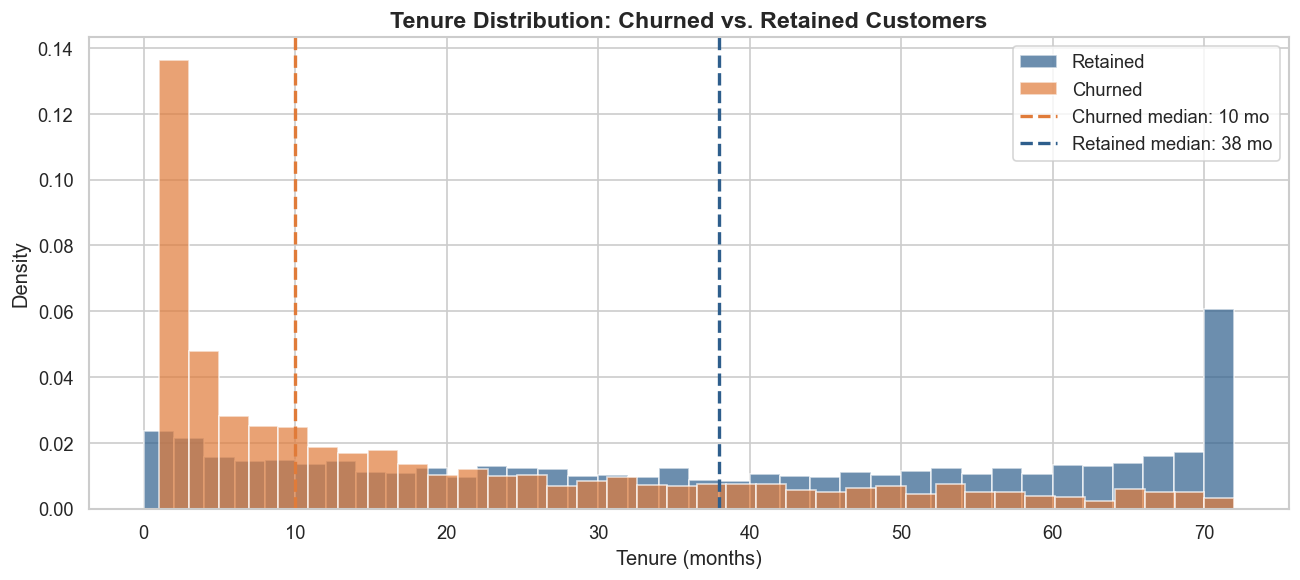


📌 Churned median tenure:     10 months
   Not-churned median tenure: 38 months


In [28]:
# ── CELL 8: Tenure Distribution by Churn ────────────
fig, ax = plt.subplots(figsize=(11, 5))

churned    = df[df['Churn'] == 'Yes']['tenure']
not_churned= df[df['Churn'] == 'No']['tenure']

ax.hist(not_churned, bins=36, alpha=0.7, color='#2E5E8C', label='Retained', density=True)
ax.hist(churned,     bins=36, alpha=0.7, color='#E07B39', label='Churned',  density=True)

ax.axvline(churned.median(),     color='#E07B39', linestyle='--', lw=2,
           label=f'Churned median: {churned.median():.0f} mo')
ax.axvline(not_churned.median(), color='#2E5E8C', linestyle='--', lw=2,
           label=f'Retained median: {not_churned.median():.0f} mo')

ax.set_xlabel('Tenure (months)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Tenure Distribution: Churned vs. Retained Customers', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/03_tenure_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📌 Churned median tenure:     {churned.median():.0f} months")
print(f"   Not-churned median tenure: {not_churned.median():.0f} months")

In [29]:
# ── CELL 9: Monthly Charges Box Plot ────────────────
df_orig = df.copy()
df_orig['Churn_label'] = df_orig['Churn'].map({'Yes': 'Churned', 'No': 'Retained'})

fig = px.box(df_orig, x='Churn_label', y='MonthlyCharges',
             color='Churn_label',
             color_discrete_map={'Retained': '#2E5E8C', 'Churned': '#E07B39'},
             title='Monthly Charges: Churned vs. Retained',
             labels={'MonthlyCharges': 'Monthly Charges ($)'})
fig.write_html('../figures/04_charges_vs_churn.html')
fig.write_image('../figures/04_charges_vs_churn.png', scale=2)
fig.show()

# Churn rate by payment method
df_orig['Churn_num'] = df_orig['Churn'].map({'Yes':1, 'No':0})
pay_churn = df_orig.groupby('PaymentMethod')['Churn_num'].mean().mul(100).sort_values(ascending=False)

fig2 = px.bar(x=pay_churn.index, y=pay_churn.values,
              title='Churn Rate by Payment Method',
              labels={'x': 'Payment Method', 'y': 'Churn Rate (%)'},
              color=pay_churn.values, color_continuous_scale='OrRd')
fig2.update_layout(coloraxis_showscale=False)
fig2.write_html('../figures/05_payment_vs_churn.html')
fig2.write_image('../figures/05_payment_vs_churn.png', scale=2)
fig2.show()

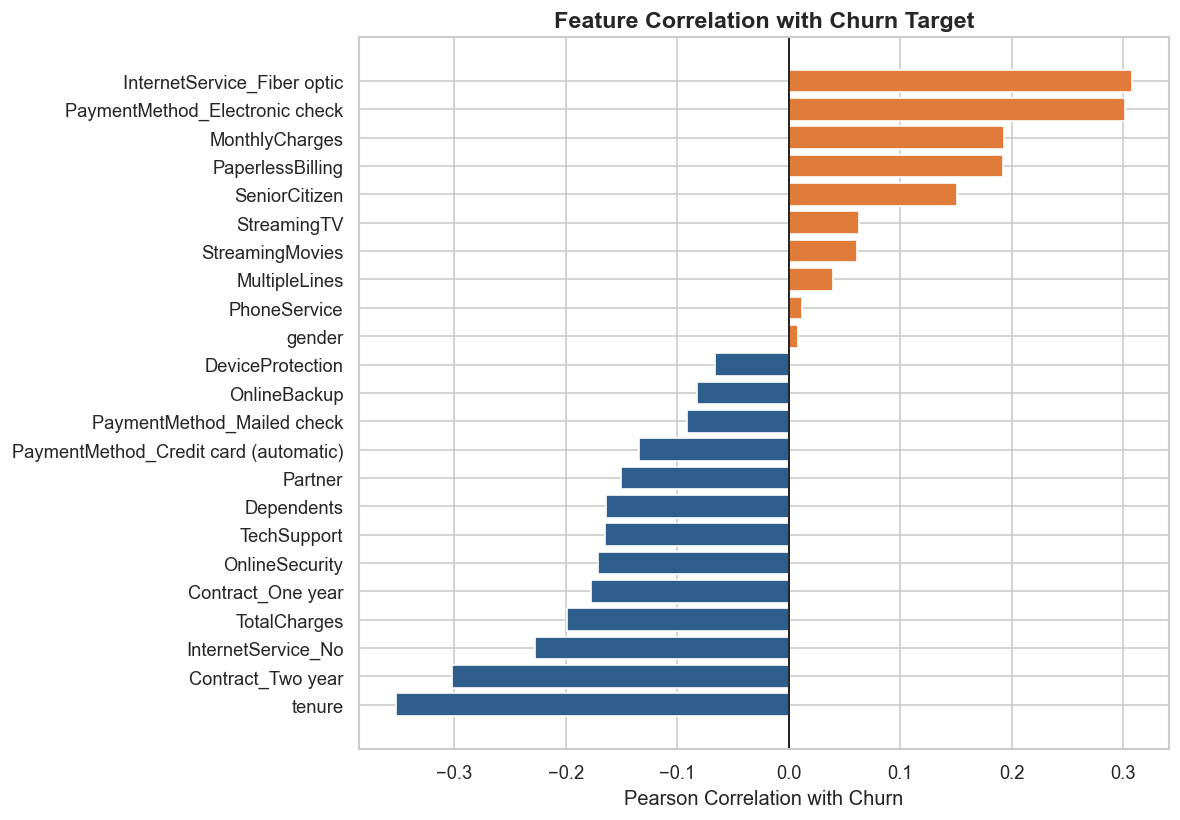


📌 TOP POSITIVE CORRELATORS (churn drivers):
SeniorCitizen                     0.150889
PaperlessBilling                  0.191825
MonthlyCharges                    0.193356
PaymentMethod_Electronic check    0.301919
InternetService_Fiber optic       0.308020
Name: Churn, dtype: float64

📌 TOP NEGATIVE CORRELATORS (retention factors):
tenure               -0.352229
Contract_Two year    -0.302253
InternetService_No   -0.227890
TotalCharges         -0.199037
Contract_One year    -0.177820
Name: Churn, dtype: float64


In [30]:
# ── CELL 10: Feature Correlation with Churn ─────────
corr_with_churn = df_clean.corr()['Churn'].drop('Churn').sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#E07B39' if v > 0 else '#2E5E8C' for v in corr_with_churn]
ax.barh(corr_with_churn.index, corr_with_churn.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Pearson Correlation with Churn')
ax.set_title('Feature Correlation with Churn Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/07_correlation_with_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 TOP POSITIVE CORRELATORS (churn drivers):")
print(corr_with_churn.tail(5))
print("\n📌 TOP NEGATIVE CORRELATORS (retention factors):")
print(corr_with_churn.head(5))

In [33]:
# ── CELL 11: Feature Engineering ────────────────────

# 11a. Tenure groups (use original df for labels)
df_feat = df_clean.copy()
df_feat['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 36, 48, 72],
    labels=[1, 2, 3, 4, 5],  # numeric labels for model compatibility
    include_lowest=True       # <--- ADD THIS LINE HERE
).astype(int)

# 11b. Number of services subscribed
service_cols = ['PhoneService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df_feat['num_services'] = df_feat[service_cols].sum(axis=1)

# 11c. Charge per service (value perception proxy)
df_feat['charge_per_service'] = df['MonthlyCharges'] / (df_feat['num_services'] + 1)

# 11d. High-value at-risk flag
tc_75pct = df['TotalCharges'].replace(' ', np.nan).astype(float).quantile(0.75)
df_feat['high_value_at_risk'] = (
    (df['TotalCharges'].replace(' ', np.nan).astype(float) > tc_75pct) &
    (df['tenure'] < 12)
).astype(int)

print("New features summary:")
print(df_feat[['tenure_group', 'num_services', 'charge_per_service', 'high_value_at_risk']].describe().round(2))

# Save
df_feat.to_csv('../data/processed/churn_features.csv', index=False)
print(f"\n✓ Feature dataset saved. Final shape: {df_feat.shape}")

New features summary:
       tenure_group  num_services  charge_per_service  high_value_at_risk
count       7043.00       7043.00             7043.00              7043.0
mean           2.98          2.94               17.08                 0.0
std            1.66          1.84                6.93                 0.0
min            1.00          0.00                8.65                 0.0
25%            1.00          1.00               11.57                 0.0
50%            3.00          3.00               15.49                 0.0
75%            5.00          4.00               20.71                 0.0
max            5.00          7.00               38.95                 0.0

✓ Feature dataset saved. Final shape: (7043, 28)


In [34]:
# ── CELL 12: Train/Test Split ───────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import joblib

# Define features and target
X = df_feat.drop(columns=['Churn'])
y = df_feat['Churn']

print(f"Feature matrix shape: {X.shape}")
print(f"Class distribution — 0: {(y==0).sum()}, 1: {(y==1).sum()}")
print(f"Churn rate: {y.mean()*100:.1f}%")

# Stratified split (preserves class ratio in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape[0]} | Test: {X_test.shape[0]}")

# Scale features for Logistic Regression only
# Tree-based models don't need scaling — never apply to RF or XGB
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Cross-validation object (used for all models)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Feature matrix shape: (7043, 27)
Class distribution — 0: 5174, 1: 1869
Churn rate: 26.5%

Train: 5634 | Test: 1409


In [35]:
# ── CELL 13: Model 1 — Logistic Regression ──────────
lr = LogisticRegression(
    class_weight='balanced',  # handles 26.5% imbalance
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_sc, y_train)

# Cross-validated AUC
lr_cv_scores = cross_val_score(lr, X_train_sc, y_train, cv=cv, scoring='roc_auc')
print(f"Logistic Regression — CV ROC-AUC: {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}")

joblib.dump(lr, '../models/logistic_regression.pkl')
print("✓ Saved logistic_regression.pkl")

Logistic Regression — CV ROC-AUC: 0.8463 ± 0.0123
✓ Saved logistic_regression.pkl


In [36]:
# ── CELL 14: Model 2 — Random Forest ────────────────
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)  # use unscaled X for tree models

rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"Random Forest — CV ROC-AUC: {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")

joblib.dump(rf, '../models/random_forest.pkl')
print("✓ Saved random_forest.pkl")

Random Forest — CV ROC-AUC: 0.8412 ± 0.0101
✓ Saved random_forest.pkl


In [37]:
# ── CELL 15: Model 3 — XGBoost ──────────────────────
# scale_pos_weight handles imbalance: neg_count / pos_count
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw = neg_count / pos_count
print(f"scale_pos_weight = {spw:.2f}")

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)

xgb_cv_scores = cross_val_score(xgb, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"XGBoost — CV ROC-AUC: {xgb_cv_scores.mean():.4f} ± {xgb_cv_scores.std():.4f}")

joblib.dump(xgb, '../models/xgboost_model.pkl')
print("✓ Saved xgboost_model.pkl")

scale_pos_weight = 2.77
XGBoost — CV ROC-AUC: 0.8395 ± 0.0093
✓ Saved xgboost_model.pkl


              Model  CV ROC-AUC (mean)  CV ROC-AUC (std)
Logistic Regression           0.846264          0.012287
      Random Forest           0.841240          0.010091
            XGBoost           0.839465          0.009305


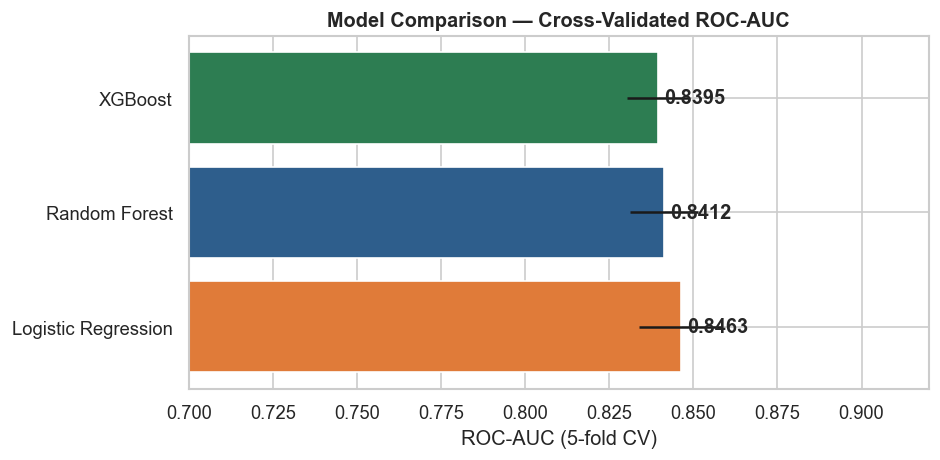

In [38]:
# ── CELL 16: Model Comparison ───────────────────────
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'CV ROC-AUC (mean)': [lr_cv_scores.mean(), rf_cv_scores.mean(), xgb_cv_scores.mean()],
    'CV ROC-AUC (std)':  [lr_cv_scores.std(),  rf_cv_scores.std(),  xgb_cv_scores.std()],
})
comparison = comparison.sort_values('CV ROC-AUC (mean)', ascending=False)
print(comparison.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(comparison['Model'], comparison['CV ROC-AUC (mean)'],
               color=['#E07B39', '#2E5E8C', '#2D7D52'],
               edgecolor='white', xerr=comparison['CV ROC-AUC (std)'])
ax.set_xlim(0.7, 0.92)
ax.set_xlabel('ROC-AUC (5-fold CV)')
ax.set_title('Model Comparison — Cross-Validated ROC-AUC', fontweight='bold')
for bar, val in zip(bars, comparison['CV ROC-AUC (mean)']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
# ── CELL 17: Evaluation ─────────────────────────────
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    confusion_matrix, precision_recall_curve, average_precision_score
)

# Predictions from final model (XGBoost)
y_pred      = xgb.predict(X_test)
y_prob      = xgb.predict_proba(X_test)[:, 1]

# Core metrics
roc_auc  = roc_auc_score(y_test, y_prob)
pr_auc   = average_precision_score(y_test, y_prob)

print("=" * 50)
print("XGBoost — TEST SET EVALUATION")
print("=" * 50)
print(f"ROC-AUC:      {roc_auc:.4f}")
print(f"PR-AUC:       {pr_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

XGBoost — TEST SET EVALUATION
ROC-AUC:      0.8364
PR-AUC:       0.6467

Classification Report:
              precision    recall  f1-score   support

    Retained       0.90      0.75      0.82      1035
     Churned       0.52      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.75      0.76      1409



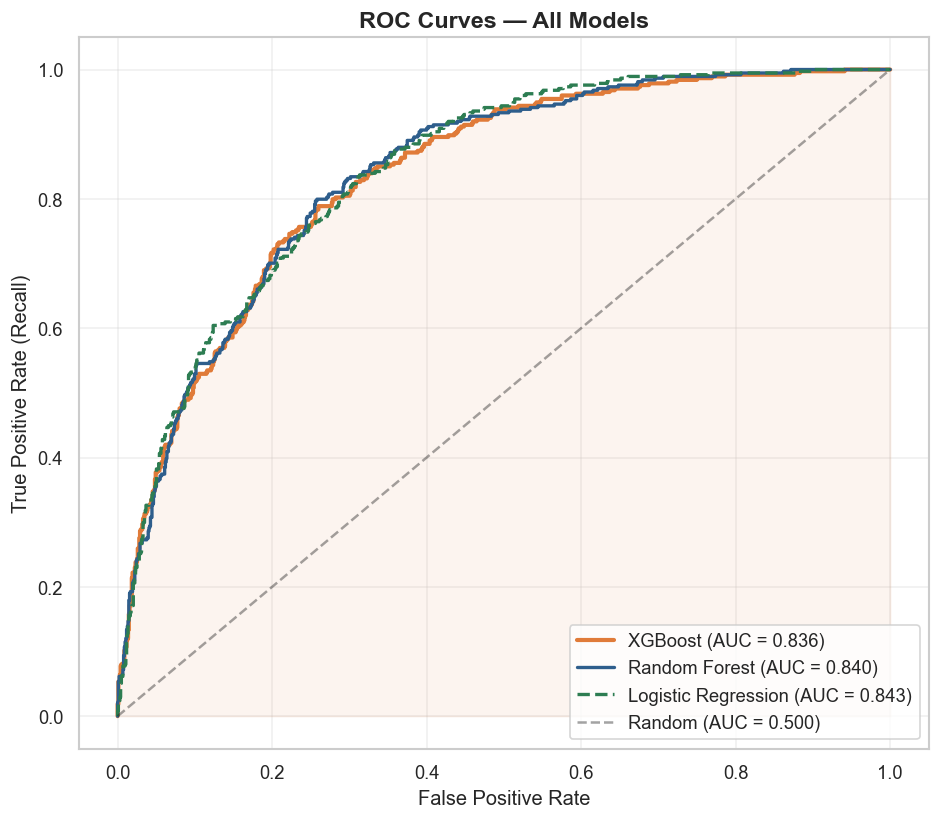

In [40]:
# ── CELL 18: ROC Curve ──────────────────────────────
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob)
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, lr.predict_proba(X_test_sc)[:, 1])
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, rf.predict_proba(X_test)[:, 1])

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(fpr_xgb, tpr_xgb, color='#E07B39', lw=2.5,
        label=f'XGBoost (AUC = {roc_auc_score(y_test, y_prob):.3f})')
ax.plot(fpr_rf,  tpr_rf,  color='#2E5E8C', lw=2,
        label=f'Random Forest (AUC = {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.3f})')
ax.plot(fpr_lr,  tpr_lr,  color='#2D7D52', lw=2, linestyle='--',
        label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:,1]):.3f})')
ax.plot([0,1], [0,1], 'k--', alpha=0.4, label='Random (AUC = 0.500)')

ax.fill_between(fpr_xgb, tpr_xgb, alpha=0.08, color='#E07B39')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/08_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

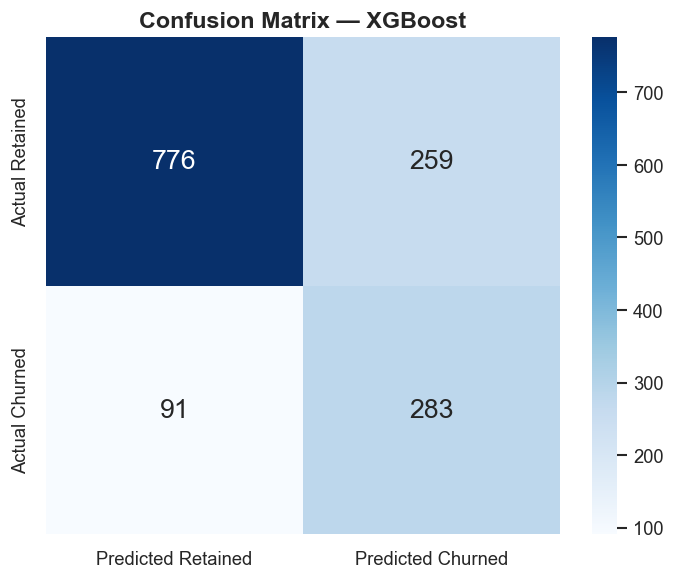


True Positives  (correctly caught churners):    283
False Negatives (missed churners — costly!):    91
False Positives (false alarms):                 259
True Negatives  (correctly retained):           776

Churner recall:    75.7%  ← most important business metric


In [41]:
# ── CELL 19: Confusion Matrix ───────────────────────
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Retained', 'Predicted Churned'],
            yticklabels=['Actual Retained', 'Actual Churned'],
            ax=ax, annot_kws={'size': 16})
ax.set_title('Confusion Matrix — XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/09_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTrue Positives  (correctly caught churners):    {tp}")
print(f"False Negatives (missed churners — costly!):    {fn}")
print(f"False Positives (false alarms):                 {fp}")
print(f"True Negatives  (correctly retained):           {tn}")
print(f"\nChurner recall:    {tp/(tp+fn)*100:.1f}%  ← most important business metric")

In [42]:
# ── CELL 20: SHAP Values ────────────────────────────
import shap

# TreeExplainer is fast and exact for tree-based models
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")
print(f"X_test shape:      {X_test.shape}")
print("✓ SHAP values computed")

SHAP values shape: (1409, 27)
X_test shape:      (1409, 27)
✓ SHAP values computed


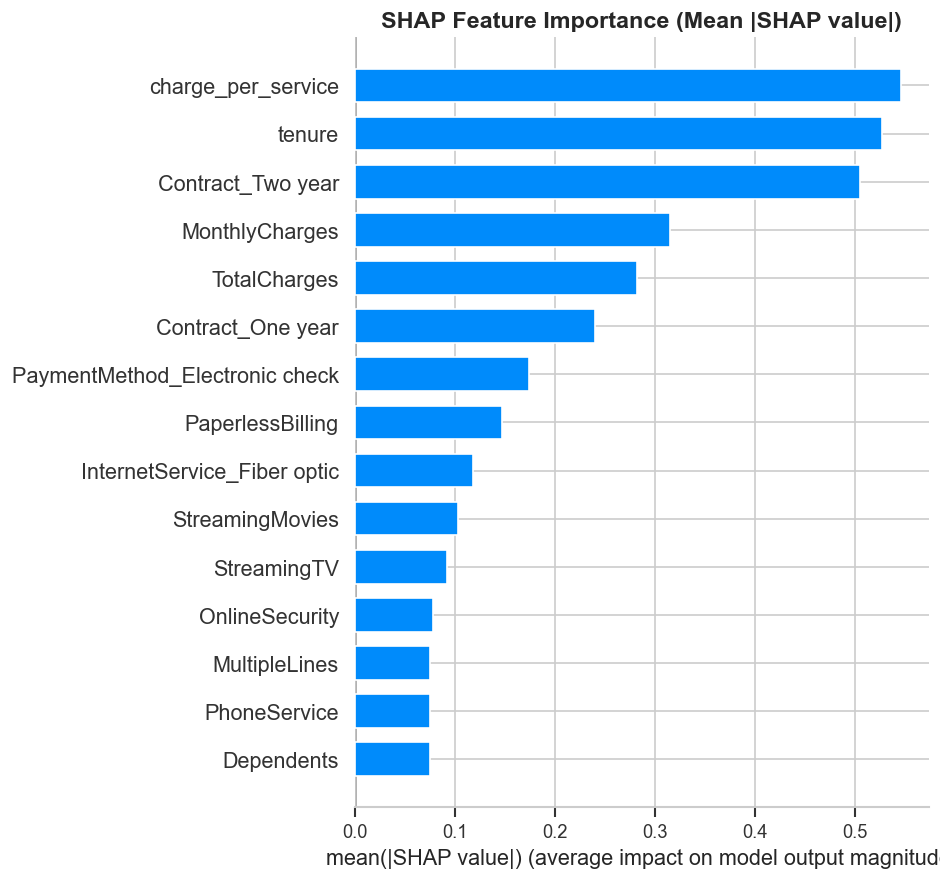

In [43]:
# ── CELL 21: SHAP Summary Bar ───────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, plot_type="bar",
                  feature_names=list(X_test.columns),
                  max_display=15, show=False)
plt.title("SHAP Feature Importance (Mean |SHAP value|)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/10_shap_importance_bar.png", dpi=150, bbox_inches="tight")
plt.show()

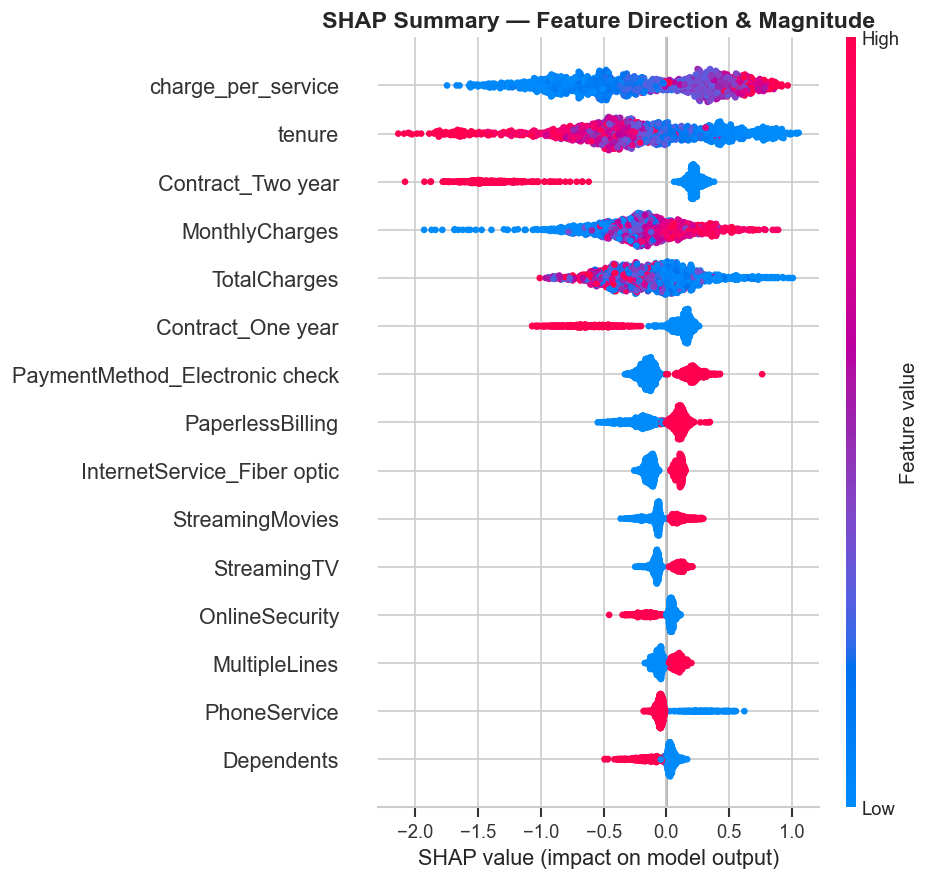


📌 KEY FINDING: Which features show red on the right side?
   (red on right = high value INCREASES churn probability)
   (blue on right = high value DECREASES churn probability)


In [44]:
# ── CELL 22: SHAP Beeswarm ──────────────────────────
# This is the most powerful SHAP plot: shows direction AND magnitude
# Red = high feature value increases churn risk
# Blue = high feature value decreases churn risk
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test,
                  feature_names=list(X_test.columns),
                  max_display=15, show=False)
plt.title("SHAP Summary — Feature Direction & Magnitude", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/11_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

# After seeing the chart, write down what you observe:
print("\n📌 KEY FINDING: Which features show red on the right side?")
print("   (red on right = high value INCREASES churn probability)")
print("   (blue on right = high value DECREASES churn probability)")

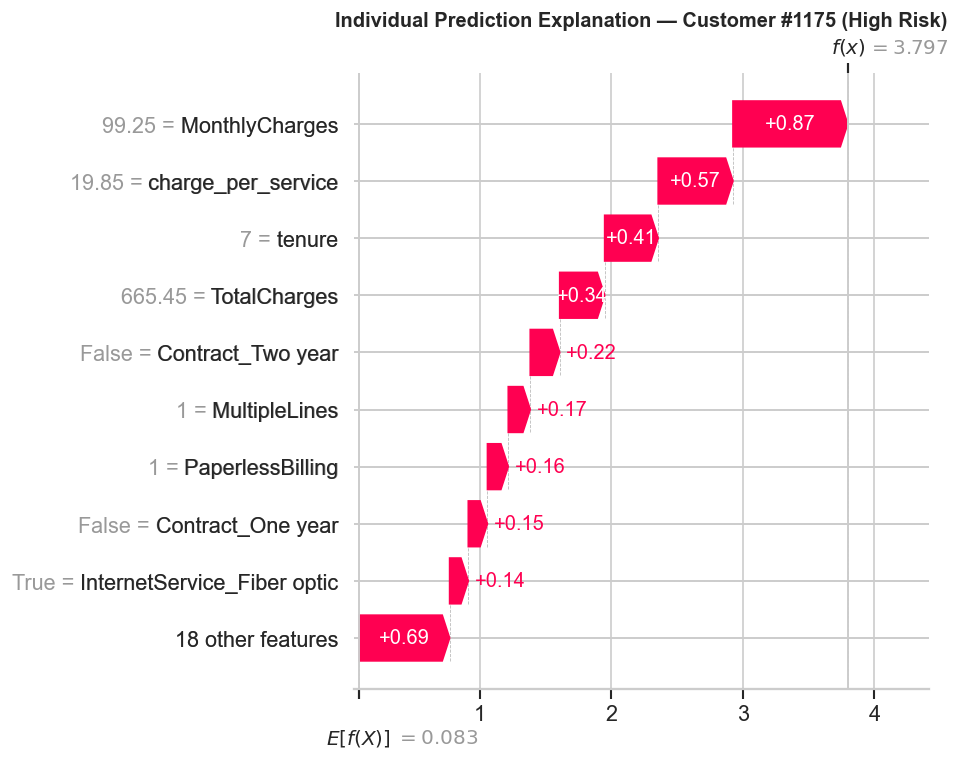


Customer predicted churn probability: 97.8%
Actual outcome: Churned


In [45]:
# ── CELL 23: Single Customer Explanation ────────────
# Pick a high-risk customer (one with high predicted churn probability)
high_risk_idx = y_prob.argsort()[-1]  # the highest-probability churner

explainer_new  = shap.Explainer(xgb)
shap_values_ex = explainer_new(X_test)

plt.figure(figsize=(10, 5))
shap.plots.waterfall(shap_values_ex[high_risk_idx], show=False)
plt.title(f"Individual Prediction Explanation — Customer #{high_risk_idx} (High Risk)",
          fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/12_shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nCustomer predicted churn probability: {y_prob[high_risk_idx]*100:.1f}%")
print(f"Actual outcome: {'Churned' if y_test.iloc[high_risk_idx] == 1 else 'Retained'}")